# Final Model Comparison and LSTM Residual Analysis

This notebook compares the selected baseline, XGBoost and the Hyperband-tuned LSTM on their common test timestamps. It then selects the final model and examines the LSTM residuals.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Mount Google Drive when the script is run in Google Colab.
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass


Mounted at /content/drive


## 1. File locations

Set the Google Drive paths used by the three completed model notebooks.

In [2]:
MODEL_OUTPUTS = Path(
    "/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs"
)

BASELINE_PATH = MODEL_OUTPUTS / "Baseline" / "baseline_predictions.parquet"
XGBOOST_PATH = MODEL_OUTPUTS / "XGBoost" / "xgboost_predictions.parquet"
LSTM_PATH = MODEL_OUTPUTS / "LSTM_Final" / "lstm_predictions.parquet"

OUTPUT_DIR = MODEL_OUTPUTS / "Model Comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load predictions and align all models by DATETIME

Load the saved predictions and keep only timestamps shared by every model.

In [3]:
baseline = pd.read_parquet(BASELINE_PATH)
xgboost = pd.read_parquet(XGBOOST_PATH)
lstm = pd.read_parquet(LSTM_PATH)

for frame in (baseline, xgboost, lstm):
    frame["DATETIME"] = pd.to_datetime(frame["DATETIME"])

baseline = baseline[
    ["DATETIME", "TOTALDEMAND", "SelectedBaseline", "SelectedBaselineName"]
].rename(
    columns={
        "TOTALDEMAND": "Actual_Baseline",
        "SelectedBaseline": "Baseline_Prediction",
    }
)

xgboost = xgboost[
    ["DATETIME", "TOTALDEMAND", "XGBoost_Prediction"]
].rename(columns={"TOTALDEMAND": "Actual_XGBoost"})

lstm = lstm[
    ["DATETIME", "TOTALDEMAND", "LSTM_Prediction"]
].rename(columns={"TOTALDEMAND": "Actual_LSTM"})

comparison = (
    baseline.merge(xgboost, on="DATETIME", how="inner", validate="one_to_one")
    .merge(lstm, on="DATETIME", how="inner", validate="one_to_one")
    .sort_values("DATETIME")
    .reset_index(drop=True)
)

if comparison.empty:
    raise ValueError("The prediction files have no common timestamps.")

# Confirm that every model was evaluated against the same actual demand values.
if not np.allclose(
    comparison["Actual_Baseline"], comparison["Actual_XGBoost"], atol=1e-6
):
    raise ValueError("Baseline and XGBoost actual-demand values do not match.")

if not np.allclose(
    comparison["Actual_Baseline"], comparison["Actual_LSTM"], atol=1e-6
):
    raise ValueError("Baseline and LSTM actual-demand values do not match.")

comparison["Actual_Demand"] = comparison["Actual_Baseline"]
comparison = comparison[
    [
        "DATETIME",
        "Actual_Demand",
        "Baseline_Prediction",
        "XGBoost_Prediction",
        "LSTM_Prediction",
        "SelectedBaselineName",
    ]
]

print("Common test observations:", f"{len(comparison):,}")
print(
    "Test period:",
    comparison["DATETIME"].min(),
    "to",
    comparison["DATETIME"].max(),
)
print("Selected baseline:", comparison["SelectedBaselineName"].iloc[0])


Common test observations: 39,235
Test period: 2018-12-21 15:00:00 to 2021-03-18 00:00:00
Selected baseline: Persistence Baseline


## 3. Evaluation metric comparison

Recalculate every metric on the same observations for a fair comparison.

In [16]:
def evaluate_model(actual, predicted, model_name):
    """Calculate the common evaluation metrics used throughout the project."""
    actual = np.asarray(actual, dtype="float64")
    predicted = np.asarray(predicted, dtype="float64")

    valid = np.isfinite(actual) & np.isfinite(predicted)
    actual = actual[valid]
    predicted = predicted[valid]
    residuals = predicted - actual

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE": np.mean(np.abs(residuals) / actual) * 100,
        "R2": r2_score(actual, predicted),
    }


selected_baseline = comparison["SelectedBaselineName"].iloc[0]

model_columns = {
    f"Baseline – {selected_baseline}": "Baseline_Prediction",
    "XGBoost": "XGBoost_Prediction",
    "LSTM": "LSTM_Prediction",
}

metric_rows = [
    evaluate_model(
        comparison["Actual_Demand"], comparison[prediction_column], model_name
    )
    for model_name, prediction_column in model_columns.items()
]

model_comparison = (
    pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
)

print("\nFINAL MODEL COMPARISON")
print(
    model_comparison.round(
        {"MAE": 2, "RMSE": 2, "MAPE": 2, "R2": 4, "Bias": 2}
    ).to_string(index=False)
)

model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
comparison.to_parquet(
    OUTPUT_DIR / "common_test_predictions.parquet", index=False
)





FINAL MODEL COMPARISON
                          Model    MAE   RMSE  MAPE     R2
                           LSTM  53.87  71.55  0.70 0.9967
                        XGBoost  61.14  83.63  0.79 0.9955
Baseline – Persistence Baseline 168.52 214.74  2.13 0.9706


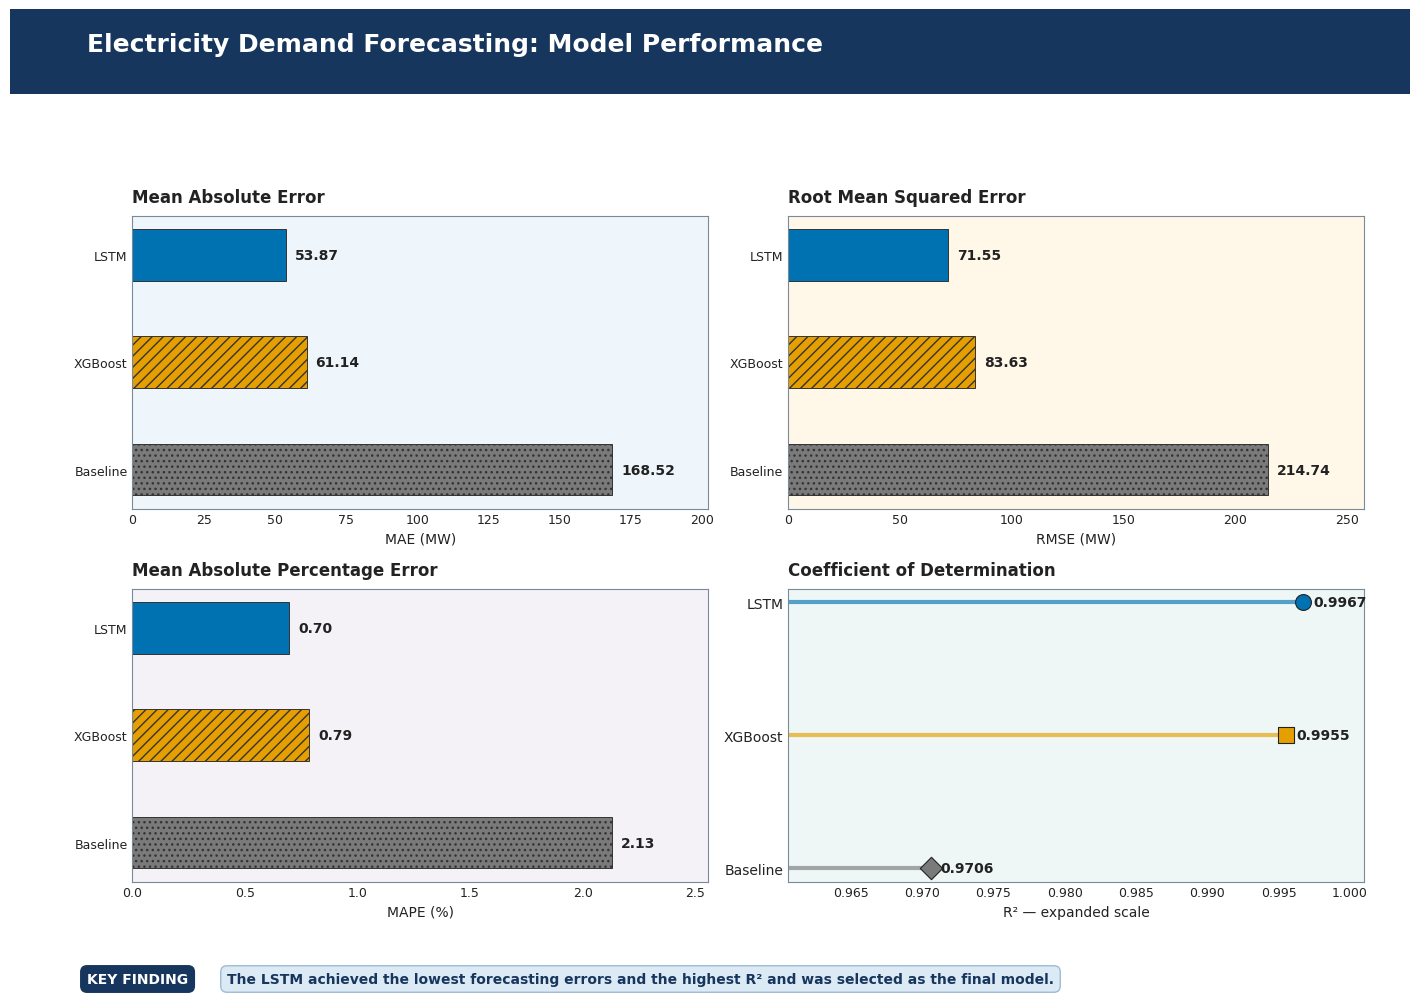

Figure saved to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Model Comparison/professional_colourblind_model_comparison.png


In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle


# ------------------------------------------------------------------
# 1. Prepare plotting data
# ------------------------------------------------------------------
plot_df = model_comparison.copy()


def display_name(name):
    if "LSTM" in name:
        return "LSTM"
    if "XGBoost" in name:
        return "XGBoost"
    if "Baseline" in name:
        return "Baseline"
    return name


plot_df["Display_Model"] = plot_df["Model"].apply(display_name)

model_order = [
    "LSTM",
    "XGBoost",
    "Baseline",
]

plot_df["Display_Model"] = pd.Categorical(
    plot_df["Display_Model"],
    categories=model_order,
    ordered=True,
)

plot_df = (
    plot_df.sort_values("Display_Model")
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# 2. Accessible colours, patterns and markers
# ------------------------------------------------------------------
# Okabe–Ito colour-blind-friendly palette
model_colours = {
    "LSTM": "#0072B2",
    "XGBoost": "#E69F00",
    "Baseline": "#7A7A7A",
}



model_hatches = {
    "LSTM": "",
    "XGBoost": "///",
    "Baseline": "...",
}

# Different marker shapes for the R² plot
model_markers = {
    "LSTM": "o",
    "XGBoost": "s",
    "Baseline": "D",
}

# Subtle coloured chart backgrounds
panel_backgrounds = [
    "#EEF6FB",  # Pale blue
    "#FFF7E8",  # Pale orange
    "#F4F1F7",  # Pale lavender
    "#EEF7F5",  # Pale teal
]

page_background = "#E7EDF2"
grid_colour = "#C7D1DA"
heading_colour = "#17365D"
text_colour = "#222222"
border_colour = "#B8C4CE"


# ------------------------------------------------------------------
# 3. Create the figure
# ------------------------------------------------------------------
plt.style.use("default")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

axes = axes.flatten()


# Apply background and formatting to every panel
for ax, background in zip(axes, panel_backgrounds):
    ax.set_facecolor(background)
    ax.grid(False)

    ax.tick_params(
        axis="both",
        colors=text_colour,
        labelsize=9,
        length=0,
    )

    for spine in ax.spines.values():
        spine.set_color("#7A8A99")
        spine.set_linewidth(0.8)


# ------------------------------------------------------------------
# 4. Add the professional header
# ------------------------------------------------------------------
header = Rectangle(
    (0, 0.915),
    1,
    0.085,
    transform=fig.transFigure,
    facecolor=heading_colour,
    edgecolor="none",
    zorder=0.5,
)

fig.add_artist(header)

fig.suptitle(
    "Electricity Demand Forecasting: Model Performance",
    x=0.055,
    y=0.977,
    ha="left",
    fontsize=18,
    fontweight="bold",
    color="white",
)




# ------------------------------------------------------------------
# 5. MAE, RMSE and MAPE plots
# ------------------------------------------------------------------
metric_settings = [
    {
        "metric": "MAE",
        "title": "Mean Absolute Error",
        "xlabel": "MAE (MW)",
        "decimals": 2,
    },
    {
        "metric": "RMSE",
        "title": "Root Mean Squared Error",
        "xlabel": "RMSE (MW)",
        "decimals": 2,
    },
    {
        "metric": "MAPE",
        "title": "Mean Absolute Percentage Error",
        "xlabel": "MAPE (%)",
        "decimals": 2,
    },
]


for ax, settings in zip(axes[:3], metric_settings):

    metric = settings["metric"]

    bars = ax.barh(
        plot_df["Display_Model"],
        plot_df[metric],
        height=0.48,
        edgecolor="#333333",
        linewidth=0.7,
    )

    # Apply a different colour and pattern to each model
    for bar, model_name in zip(
        bars,
        plot_df["Display_Model"].astype(str),
    ):
        bar.set_facecolor(model_colours[model_name])
        bar.set_hatch(model_hatches[model_name])

    ax.invert_yaxis()

    ax.set_title(
        f'{settings["title"]}',
        loc="left",
        fontsize=12,
        fontweight="bold",
        color=text_colour,
        pad=10,
    )

    ax.set_xlabel(
        settings["xlabel"],
        fontsize=10,
        color=text_colour,
    )

    ax.set_ylabel("")

    upper_limit = plot_df[metric].max() * 1.20
    ax.set_xlim(0, upper_limit)

    # Add values beside each bar
    for bar, value in zip(bars, plot_df[metric]):

        ax.text(
            value + upper_limit * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.{settings["decimals"]}f}',
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color=text_colour,
        )


# ------------------------------------------------------------------
# 6. R² dot plot
# ------------------------------------------------------------------
ax = axes[3]

r2_min = max(
    0,
    plot_df["R2"].min() - 0.01,
)

r2_max = 1.001
y_positions = np.arange(len(plot_df))


for y_position, (_, row) in zip(
    y_positions,
    plot_df.iterrows(),
):

    model_name = str(row["Display_Model"])
    colour = model_colours[model_name]
    marker = model_markers[model_name]

    # Horizontal connecting line
    ax.hlines(
        y=y_position,
        xmin=r2_min,
        xmax=row["R2"],
        color=colour,
        linewidth=3,
        alpha=0.65,
    )

    # Accessible marker
    ax.scatter(
        row["R2"],
        y_position,
        s=130,
        color=colour,
        marker=marker,
        edgecolor="#222222",
        linewidth=0.8,
        zorder=3,
    )

    # R² value
    ax.text(
        row["R2"] + 0.0007,
        y_position,
        f'{row["R2"]:.4f}',
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_colour,
    )


ax.set_yticks(y_positions)

ax.set_yticklabels(
    plot_df["Display_Model"],
    fontsize=10,
)

ax.invert_yaxis()

ax.set_xlim(
    r2_min,
    r2_max,
)

ax.set_title(
    "Coefficient of Determination",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color=text_colour,
    pad=10,
)

ax.set_xlabel(
    "R² — expanded scale",
    fontsize=10,
    color=text_colour,
)

ax.set_ylabel("")




# ------------------------------------------------------------------
# 8. Highlight the final conclusion
# ------------------------------------------------------------------
fig.text(
    0.055,
    0.026,
    "KEY FINDING",
    fontsize=10,
    fontweight="bold",
    color="white",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": heading_colour,
        "edgecolor": heading_colour,
    },
)

fig.text(
    0.155,
    0.026,
    "The LSTM achieved the lowest forecasting errors "
    "and the highest R² and was selected as the final model.",
    fontsize=10,
    color=heading_colour,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#DCEAF5",
        "edgecolor": "#9EBBD2",
    },
)


# ------------------------------------------------------------------
# 9. Final layout and save
# ------------------------------------------------------------------
plt.tight_layout(
    rect=[0.035, 0.075, 0.985, 0.875]
)

figure_path = (
    OUTPUT_DIR
    / "professional_colourblind_model_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=page_background,
)

plt.show()

print("Figure saved to:", figure_path)

## 4. Actual versus predicted demand for all models

Plot a readable fourteen-day test window for each model.

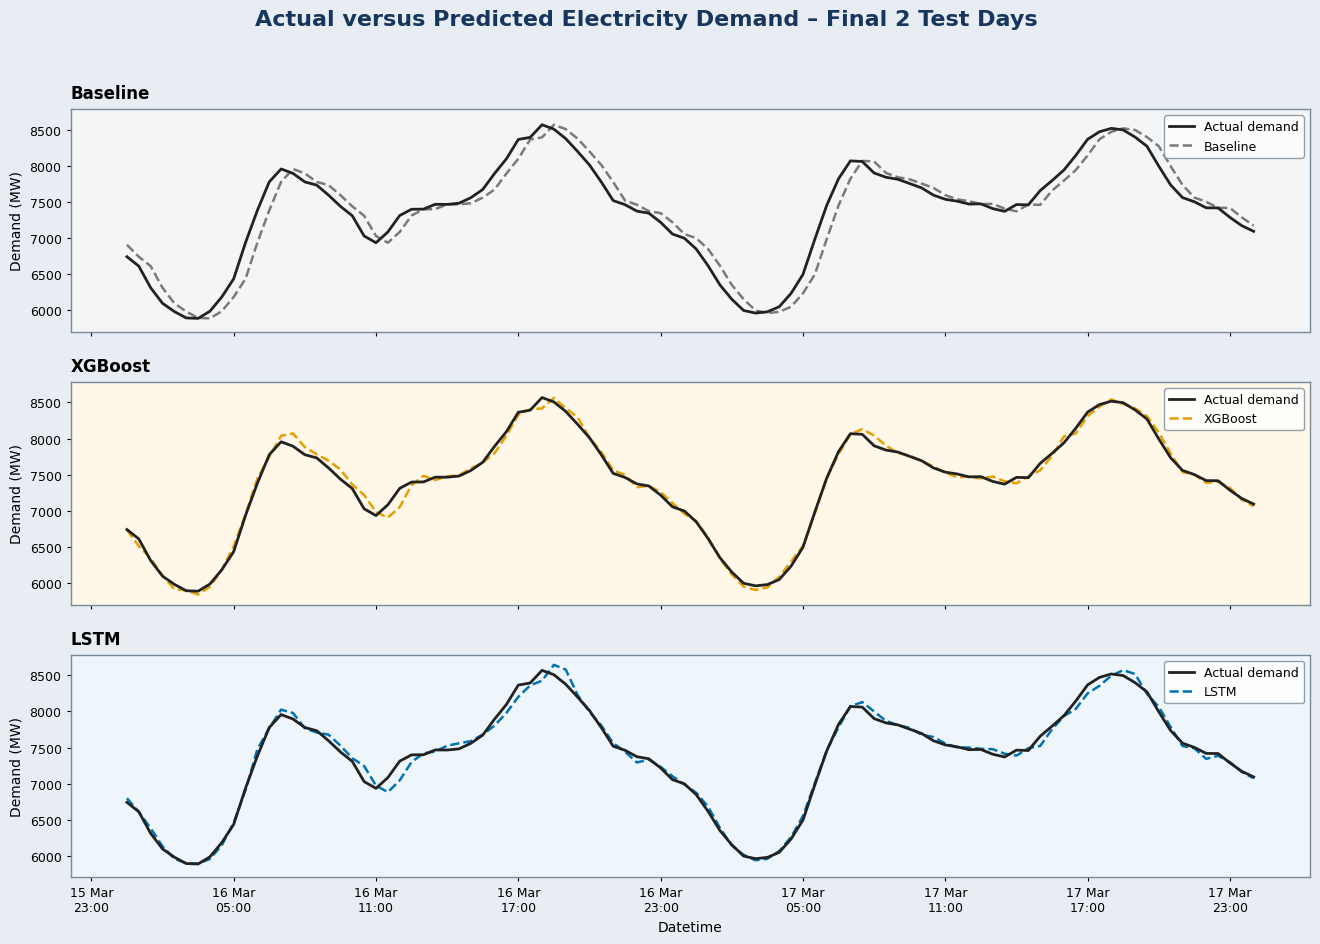

Figure saved to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Model Comparison/02_actual_vs_predicted_all_models.png


In [50]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt


# Two days of half-hourly observations
DAYS_TO_PLOT = 2
PERIODS_PER_DAY = 48

plot_periods = min(
    DAYS_TO_PLOT * PERIODS_PER_DAY,
    len(comparison)
)

plot_data = comparison.tail(plot_periods).copy()


# Colour-blind-friendly colours
actual_colour = "#222222"
baseline_colour = "#7A7A7A"
xgboost_colour = "#E69F00"
lstm_colour = "#0072B2"

panel_backgrounds = [
    "#F3F5F7",
    "#FFF7E8",
    "#EEF6FB",
]

prediction_plots = [
    (
        "Baseline_Prediction",
        "Baseline",
        baseline_colour,
    ),
    (
        "XGBoost_Prediction",
        "XGBoost",
        xgboost_colour,
    ),
    (
        "LSTM_Prediction",
        "LSTM",
        lstm_colour,
    ),
]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True,
    sharey=True,
)

fig.patch.set_facecolor("#E7EDF2")


for ax, (
    prediction_column,
    model_name,
    model_colour,
), background in zip(
    axes,
    prediction_plots,
    panel_backgrounds,
):

    ax.set_facecolor(background)

    # Actual demand
    ax.plot(
        plot_data["DATETIME"],
        plot_data["Actual_Demand"],
        label="Actual demand",
        color=actual_colour,
        linewidth=2.0,
        zorder=3,
    )

    # Model prediction
    ax.plot(
        plot_data["DATETIME"],
        plot_data[prediction_column],
        label=model_name,
        color=model_colour,
        linewidth=1.8,
        linestyle="--",
        zorder=2,
    )

    ax.set_title(
        model_name,
        fontsize=12,
        fontweight="bold",
        loc="left",
        pad=8,
    )

    ax.set_ylabel(
        "Demand (MW)",
        fontsize=10,
    )

    ax.grid(False)

    ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="#7A8A99",
        fontsize=9,
    )

    ax.tick_params(
        axis="both",
        labelsize=9,
        length=3,
    )

    for spine in ax.spines.values():
        spine.set_color("#7A8A99")
        spine.set_linewidth(1.0)


# Display time every six hours
axes[-1].xaxis.set_major_locator(
    mdates.HourLocator(interval=6)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b\n%H:%M")
)

axes[-1].set_xlabel(
    "Datetime",
    fontsize=10,
)


fig.suptitle(
    "Actual versus Predicted Electricity Demand – Final 2 Test Days",
    fontsize=16,
    fontweight="bold",
    color="#17365D",
    y=0.975,
)


plt.tight_layout(
    rect=[0.035, 0.035, 0.985, 0.95],
    h_pad=1.5,
)


figure_path = (
    OUTPUT_DIR
    / "02_actual_vs_predicted_all_models.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print("Figure saved to:", figure_path)

Residual observations: 39,235
Mean residual: 0.83 MW
MAE: 53.87 MW


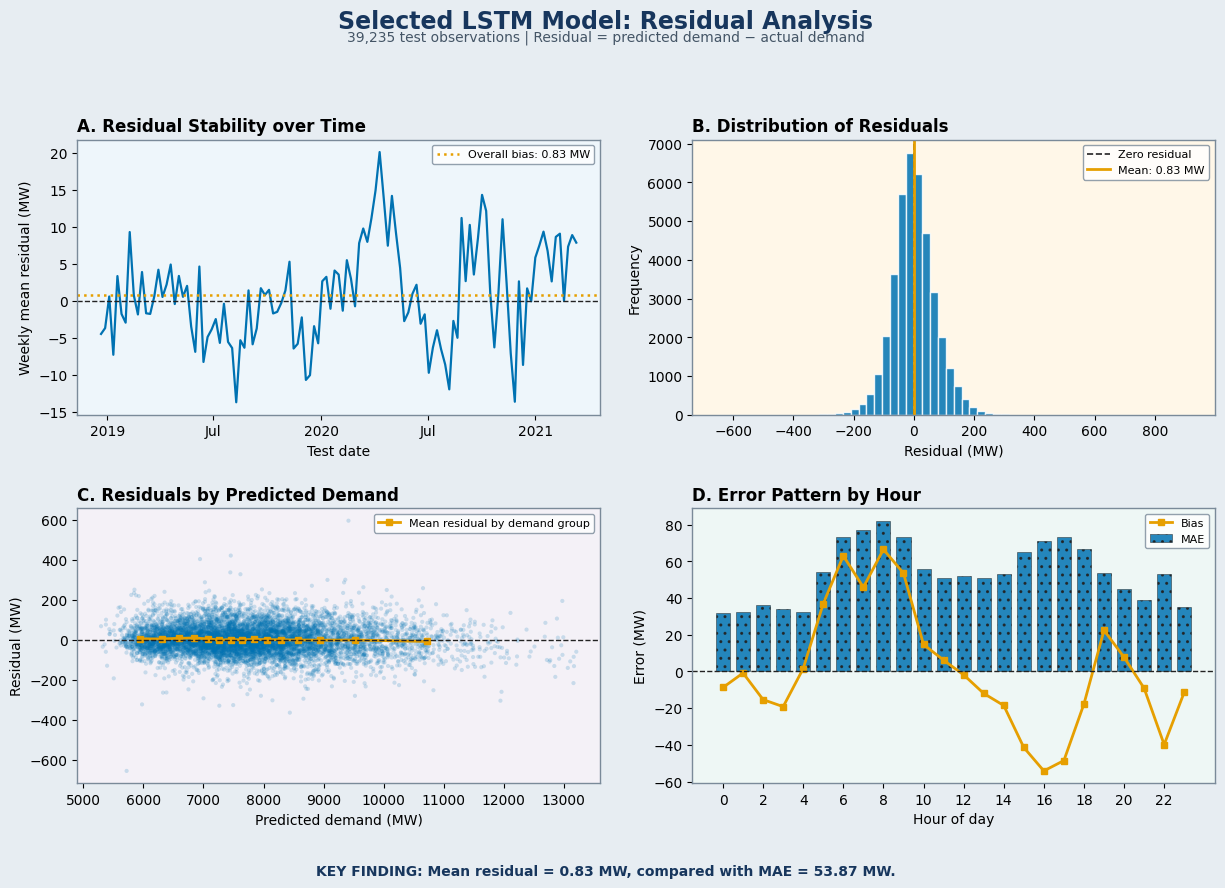

Figure saved to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Model Comparison/03_lstm_residual_analysis.png


In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Prepare and validate residual data
# ------------------------------------------------------------
residual_data = comparison[
    ["DATETIME", "Actual_Demand", "LSTM_Prediction"]
].copy()

residual_data["DATETIME"] = pd.to_datetime(
    residual_data["DATETIME"],
    errors="coerce"
)

residual_data["Actual_Demand"] = pd.to_numeric(
    residual_data["Actual_Demand"],
    errors="coerce"
)

residual_data["LSTM_Prediction"] = pd.to_numeric(
    residual_data["LSTM_Prediction"],
    errors="coerce"
)

residual_data = (
    residual_data
    .dropna()
    .sort_values("DATETIME")
    .reset_index(drop=True)
)

residual_data["Residual"] = (
    residual_data["LSTM_Prediction"]
    - residual_data["Actual_Demand"]
)

residual_data["Absolute_Error"] = residual_data["Residual"].abs()
residual_data["Hour"] = residual_data["DATETIME"].dt.hour

if residual_data.empty:
    raise ValueError("No valid LSTM residual data are available.")

print("Residual observations:", f"{len(residual_data):,}")
print("Mean residual:", round(residual_data["Residual"].mean(), 2), "MW")
print("MAE:", round(residual_data["Absolute_Error"].mean(), 2), "MW")


# ------------------------------------------------------------
# 2. Prepare chart summaries
# ------------------------------------------------------------
# Weekly means create a readable time-series diagnostic.
weekly_residuals = (
    residual_data
    .set_index("DATETIME")["Residual"]
    .resample("7D")
    .mean()
    .dropna()
)

# Sample the scatter plot to avoid overplotting.
scatter_data = residual_data.sample(
    n=min(8000, len(residual_data)),
    random_state=42
)

# Mean residual across predicted-demand ranges.
residual_data["Demand_Group"] = pd.qcut(
    residual_data["LSTM_Prediction"],
    q=15,
    duplicates="drop"
)

demand_residuals = (
    residual_data
    .groupby("Demand_Group", observed=True)
    .agg(
        Predicted_Demand=("LSTM_Prediction", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .reset_index(drop=True)
)

hourly_errors = (
    residual_data
    .groupby("Hour")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Bias=("Residual", "mean")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Colours and figure
# ------------------------------------------------------------
blue = "#0072B2"
orange = "#E69F00"
black = "#222222"

page_background = "#E7EDF2"
border_colour = "#7A8A99"

panel_backgrounds = [
    "#EEF6FB",
    "#FFF7E8",
    "#F4F1F7",
    "#EEF7F5"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)

axes = axes.flatten()
fig.patch.set_facecolor(page_background)

for ax, background in zip(axes, panel_backgrounds):
    ax.set_facecolor(background)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color(border_colour)
        spine.set_linewidth(1.0)


# ------------------------------------------------------------
# A. Residual stability over time
# ------------------------------------------------------------
ax = axes[0]

ax.plot(
    weekly_residuals.index,
    weekly_residuals.values,
    color=blue,
    linewidth=1.6
)

ax.axhline(
    0,
    color=black,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    residual_data["Residual"].mean(),
    color=orange,
    linestyle=":",
    linewidth=1.8,
    label=f'Overall bias: {residual_data["Residual"].mean():.2f} MW'
)

ax.set_title(
    "A. Residual Stability over Time",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Test date")
ax.set_ylabel("Weekly mean residual (MW)")

ax.xaxis.set_major_locator(
    mdates.AutoDateLocator(minticks=4, maxticks=7)
)

ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
)

ax.legend(
    fontsize=8,
    facecolor="white",
    edgecolor=border_colour
)


# ------------------------------------------------------------
# B. Residual distribution
# ------------------------------------------------------------
ax = axes[1]

ax.hist(
    residual_data["Residual"],
    bins=60,
    color=blue,
    alpha=0.85,
    edgecolor="white"
)

ax.axvline(
    0,
    color=black,
    linestyle="--",
    linewidth=1.2,
    label="Zero residual"
)

ax.axvline(
    residual_data["Residual"].mean(),
    color=orange,
    linewidth=2,
    label=f'Mean: {residual_data["Residual"].mean():.2f} MW'
)

ax.set_title(
    "B. Distribution of Residuals",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Residual (MW)")
ax.set_ylabel("Frequency")

ax.legend(
    fontsize=8,
    facecolor="white",
    edgecolor=border_colour
)


# ------------------------------------------------------------
# C. Residuals versus predicted demand
# ------------------------------------------------------------
ax = axes[2]

ax.scatter(
    scatter_data["LSTM_Prediction"],
    scatter_data["Residual"],
    s=9,
    color=blue,
    alpha=0.18,
    edgecolor="none"
)

ax.plot(
    demand_residuals["Predicted_Demand"],
    demand_residuals["Mean_Residual"],
    color=orange,
    marker="s",
    markersize=4,
    linewidth=2,
    label="Mean residual by demand group"
)

ax.axhline(
    0,
    color=black,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "C. Residuals by Predicted Demand",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Predicted demand (MW)")
ax.set_ylabel("Residual (MW)")

ax.legend(
    fontsize=8,
    facecolor="white",
    edgecolor=border_colour
)


# ------------------------------------------------------------
# D. Error pattern by hour
# ------------------------------------------------------------
ax = axes[3]

bars = ax.bar(
    hourly_errors["Hour"],
    hourly_errors["MAE"],
    color=blue,
    alpha=0.85,
    width=0.7,
    edgecolor=black,
    linewidth=0.4,
    label="MAE"
)

for bar in bars:
    bar.set_hatch("..")

ax.plot(
    hourly_errors["Hour"],
    hourly_errors["Bias"],
    color=orange,
    marker="s",
    markersize=4,
    linewidth=2,
    label="Bias"
)

ax.axhline(
    0,
    color=black,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "D. Error Pattern by Hour",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Error (MW)")
ax.set_xticks(range(0, 24, 2))

ax.legend(
    fontsize=8,
    facecolor="white",
    edgecolor=border_colour
)


# ------------------------------------------------------------
# 4. Title, conclusion and save
# ------------------------------------------------------------
fig.suptitle(
    "Selected LSTM Model: Residual Analysis",
    fontsize=17,
    fontweight="bold",
    color="#17365D",
    y=0.98
)

fig.text(
    0.5,
    0.945,
    (
        f'{len(residual_data):,} test observations | '
        'Residual = predicted demand − actual demand'
    ),
    ha="center",
    fontsize=10,
    color="#445566"
)

fig.text(
    0.5,
    0.018,
    (
        f'KEY FINDING: Mean residual = '
        f'{residual_data["Residual"].mean():.2f} MW, compared with '
        f'MAE = {residual_data["Absolute_Error"].mean():.2f} MW.'
    ),
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#17365D"
)

plt.tight_layout(
    rect=[0.03, 0.055, 0.98, 0.92],
    h_pad=2,
    w_pad=2
)

figure_path = OUTPUT_DIR / "03_lstm_residual_analysis.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=page_background
)

plt.show()

print("Figure saved to:", figure_path)

Matched observations: 39,235
Temperature range: 1.4°C to 44.7°C


,Temperature,Actual_Demand,AEMO_Forecast,LSTM_Prediction,Observations
0,3.2,7689.4,7683.1,7690.600098,138
1,5.1,7851.4,7846.2,7853.500000,612
2,7.0,8008.3,8018.4,8008.200195,1131
3,9.0,7985.6,8004.6,7994.399902,1878
4,11.0,8049.4,8071.6,8054.500000,2707
5,13.0,8138.5,8161.9,8142.200195,3315
6,15.0,7842.1,7858.6,7844.200195,3862
7,17.0,7333.4,7350.0,7334.399902,4466
8,19.0,7241.7,7259.3,7244.899902,5574
9,20.9,7426.5,7442.8,7428.399902,5838


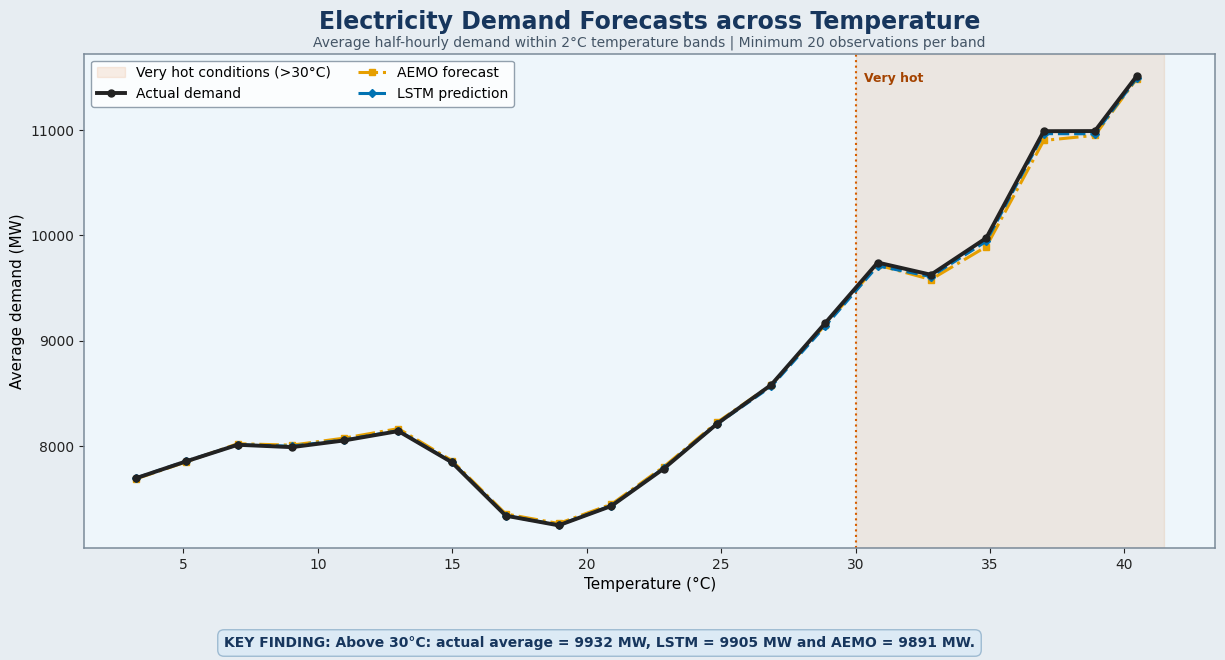

Figure saved to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Model Comparison/04_demand_forecasts_across_temperature.png


In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# 1. Prepare temperature data
# ------------------------------------------------------------------
DATA_PATH = (
    "/content/drive/My Drive/"
    "NSW_Electricity_Demand/Data/Processed/Data.parquet"
)

weather_data = pd.read_parquet(
    DATA_PATH,
    columns=[
        "DATETIME",
        "TEMPERATURE",
        "FORECASTDEMAND",
    ],
)

weather_data["DATETIME"] = pd.to_datetime(
    weather_data["DATETIME"]
)

weather_data["TEMPERATURE"] = pd.to_numeric(
    weather_data["TEMPERATURE"],
    errors="coerce",
)

weather_data["FORECASTDEMAND"] = pd.to_numeric(
    weather_data["FORECASTDEMAND"],
    errors="coerce",
)


temperature_data = comparison[
    [
        "DATETIME",
        "Actual_Demand",
        "LSTM_Prediction",
    ]
].merge(
    weather_data,
    on="DATETIME",
    how="left",
    validate="one_to_one",
)

temperature_data = (
    temperature_data
    .dropna(
        subset=[
            "Actual_Demand",
            "LSTM_Prediction",
            "FORECASTDEMAND",
            "TEMPERATURE",
        ]
    )
    .sort_values("DATETIME")
    .reset_index(drop=True)
)

if temperature_data.empty:
    raise ValueError(
        "No temperature observations matched the test predictions."
    )

print(
    "Matched observations:",
    f"{len(temperature_data):,}",
)

print(
    "Temperature range:",
    f'{temperature_data["TEMPERATURE"].min():.1f}°C',
    "to",
    f'{temperature_data["TEMPERATURE"].max():.1f}°C',
)


# ------------------------------------------------------------------
# 2. Create 2°C temperature bands
# ------------------------------------------------------------------
bin_width = 2

minimum_temperature = (
    np.floor(
        temperature_data["TEMPERATURE"].min()
        / bin_width
    )
    * bin_width
)

maximum_temperature = (
    np.ceil(
        temperature_data["TEMPERATURE"].max()
        / bin_width
    )
    * bin_width
)

temperature_edges = np.arange(
    minimum_temperature,
    maximum_temperature + bin_width,
    bin_width,
)

temperature_data["Temperature_Band"] = pd.cut(
    temperature_data["TEMPERATURE"],
    bins=temperature_edges,
    include_lowest=True,
    right=False,
)


# ------------------------------------------------------------------
# 3. Calculate average demand in each temperature band
# ------------------------------------------------------------------
temperature_profile = (
    temperature_data
    .groupby(
        "Temperature_Band",
        observed=True,
    )
    .agg(
        Temperature=("TEMPERATURE", "mean"),
        Actual_Demand=("Actual_Demand", "mean"),
        AEMO_Forecast=("FORECASTDEMAND", "mean"),
        LSTM_Prediction=("LSTM_Prediction", "mean"),
        Observations=("DATETIME", "size"),
    )
    .reset_index(drop=True)
    .sort_values("Temperature")
)

# Remove temperature bands with very few observations.
# This prevents unstable averages at the extreme ends.
MINIMUM_OBSERVATIONS = 20

temperature_profile = temperature_profile[
    temperature_profile["Observations"]
    >= MINIMUM_OBSERVATIONS
].reset_index(drop=True)

if temperature_profile.empty:
    raise ValueError(
        "No temperature bands contain enough observations."
    )

display(
    temperature_profile.round(
        {
            "Temperature": 1,
            "Actual_Demand": 1,
            "AEMO_Forecast": 1,
            "LSTM_Prediction": 1,
        }
    )
)


# ------------------------------------------------------------------
# 4. Colour-blind-friendly styling
# ------------------------------------------------------------------
# Okabe–Ito palette
actual_colour = "#222222"
lstm_colour = "#0072B2"
aemo_colour = "#E69F00"

page_background = "#E7EDF2"
panel_background = "#EEF6FB"
border_colour = "#7A8A99"
heading_colour = "#17365D"


# ------------------------------------------------------------------
# 5. Plot demand across temperature
# ------------------------------------------------------------------
plt.style.use("default")

fig, ax = plt.subplots(
    figsize=(13, 7),
)

fig.patch.set_facecolor(page_background)
ax.set_facecolor(panel_background)
ax.grid(False)


# Highlight very hot conditions
ax.axvspan(
    30,
    temperature_profile["Temperature"].max() + 1,
    color="#D55E00",
    alpha=0.10,
    label="Very hot conditions (>30°C)",
)


# Actual demand
ax.plot(
    temperature_profile["Temperature"],
    temperature_profile["Actual_Demand"],
    color=actual_colour,
    linewidth=2.8,
    marker="o",
    markersize=5,
    label="Actual demand",
    zorder=4,
)


# AEMO forecast
ax.plot(
    temperature_profile["Temperature"],
    temperature_profile["AEMO_Forecast"],
    color=aemo_colour,
    linewidth=2.2,
    linestyle="-.",
    marker="s",
    markersize=5,
    label="AEMO forecast",
    zorder=3,
)


# LSTM prediction
ax.plot(
    temperature_profile["Temperature"],
    temperature_profile["LSTM_Prediction"],
    color=lstm_colour,
    linewidth=2.2,
    linestyle="--",
    marker="D",
    markersize=4.5,
    label="LSTM prediction",
    zorder=3,
)


# Mark the high-temperature threshold
ax.axvline(
    30,
    color="#D55E00",
    linestyle=":",
    linewidth=1.5,
)

ax.text(
    30.3,
    ax.get_ylim()[1] * 0.985,
    "Very hot",
    color="#A44300",
    fontsize=9,
    fontweight="bold",
    va="top",
)


# ------------------------------------------------------------------
# 6. Labels and formatting
# ------------------------------------------------------------------
ax.set_title(
    "Electricity Demand Forecasts across Temperature",
    fontsize=17,
    fontweight="bold",
    color=heading_colour,
    pad=18,
)

ax.text(
    0.5,
    1.015,
    (
        "Average half-hourly demand within 2°C temperature bands | "
        f"Minimum {MINIMUM_OBSERVATIONS} observations per band"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#445566",
)

ax.set_xlabel(
    "Temperature (°C)",
    fontsize=11,
)

ax.set_ylabel(
    "Average demand (MW)",
    fontsize=11,
)

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#222222",
)

for spine in ax.spines.values():
    spine.set_color(border_colour)
    spine.set_linewidth(1.1)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor=border_colour,
    fontsize=10,
    ncol=2,
)


# ------------------------------------------------------------------
# 7. Add high-temperature finding
# ------------------------------------------------------------------
hot_data = temperature_data[
    temperature_data["TEMPERATURE"] >= 30
]

if not hot_data.empty:

    hot_actual = hot_data["Actual_Demand"].mean()
    hot_lstm = hot_data["LSTM_Prediction"].mean()
    hot_aemo = hot_data["FORECASTDEMAND"].mean()

    finding = (
        f"Above 30°C: actual average = {hot_actual:.0f} MW, "
        f"LSTM = {hot_lstm:.0f} MW and AEMO = {hot_aemo:.0f} MW."
    )

else:

    finding = (
        "No observations above 30°C were available in the common test period."
    )


fig.text(
    0.5,
    0.018,
    f"KEY FINDING: {finding}",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=heading_colour,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#DCEAF5",
        "edgecolor": "#9EBBD2",
    },
)


# ------------------------------------------------------------------
# 8. Save output
# ------------------------------------------------------------------
plt.tight_layout(
    rect=[
        0.035,
        0.075,
        0.985,
        0.95,
    ]
)

figure_path = (
    OUTPUT_DIR
    / "04_demand_forecasts_across_temperature.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=page_background,
)

plt.show()


temperature_profile.to_csv(
    OUTPUT_DIR
    / "demand_forecasts_across_temperature.csv",
    index=False,
)

print("Figure saved to:", figure_path)

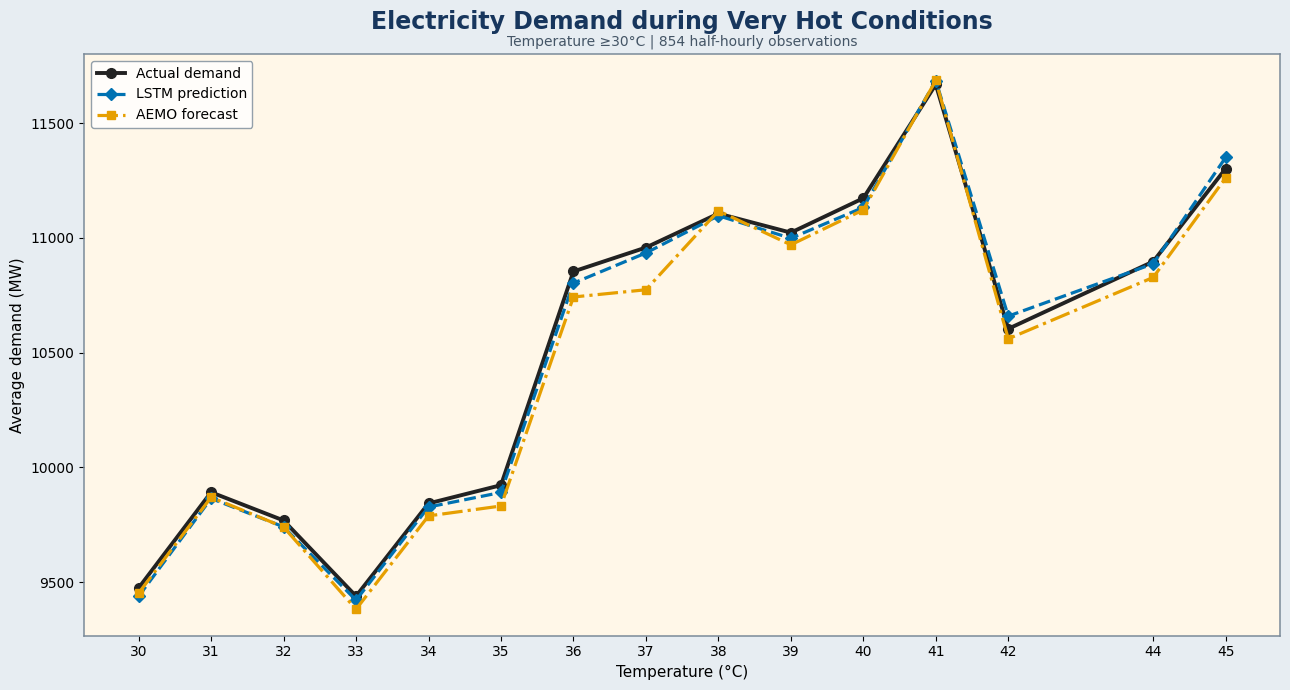

Figure saved to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Model Comparison/04_demand_during_very_hot_conditions.png


In [59]:
import matplotlib.pyplot as plt


# Keep only very hot conditions
hot_data = temperature_data[
    temperature_data["TEMPERATURE"] >= 30
].copy()


# Round temperature to the nearest degree
hot_data["Temperature"] = (
    hot_data["TEMPERATURE"].round()
)


# Calculate average demand at each temperature
hot_plot = (
    hot_data
    .groupby("Temperature")
    .agg(
        Actual_Demand=("Actual_Demand", "mean"),
        LSTM_Prediction=("LSTM_Prediction", "mean"),
        AEMO_Forecast=("FORECASTDEMAND", "mean"),
        Observations=("DATETIME", "size"),
    )
    .reset_index()
    .sort_values("Temperature")
)


# Colour-blind-friendly colours
actual_colour = "#222222"
lstm_colour = "#0072B2"
aemo_colour = "#E69F00"

page_background = "#E7EDF2"
panel_background = "#FFF7E8"
border_colour = "#7A8A99"
heading_colour = "#17365D"


# Create chart
fig, ax = plt.subplots(
    figsize=(13, 7)
)

fig.patch.set_facecolor(page_background)
ax.set_facecolor(panel_background)
ax.grid(False)


# Actual demand
ax.plot(
    hot_plot["Temperature"],
    hot_plot["Actual_Demand"],
    color=actual_colour,
    linewidth=2.8,
    marker="o",
    markersize=7,
    label="Actual demand",
)


# LSTM prediction
ax.plot(
    hot_plot["Temperature"],
    hot_plot["LSTM_Prediction"],
    color=lstm_colour,
    linewidth=2.3,
    linestyle="--",
    marker="D",
    markersize=6,
    label="LSTM prediction",
)


# AEMO forecast
ax.plot(
    hot_plot["Temperature"],
    hot_plot["AEMO_Forecast"],
    color=aemo_colour,
    linewidth=2.3,
    linestyle="-.",
    marker="s",
    markersize=6,
    label="AEMO forecast",
)


# Titles and labels
ax.set_title(
    "Electricity Demand during Very Hot Conditions",
    fontsize=17,
    fontweight="bold",
    color=heading_colour,
    pad=18,
)

ax.text(
    0.5,
    1.015,
    (
        f"Temperature ≥30°C | "
        f"{len(hot_data):,} half-hourly observations"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#445566",
)

ax.set_xlabel(
    "Temperature (°C)",
    fontsize=11,
)

ax.set_ylabel(
    "Average demand (MW)",
    fontsize=11,
)

ax.set_xticks(
    hot_plot["Temperature"]
)

ax.tick_params(
    axis="both",
    labelsize=10,
)


# Darker panel outline
for spine in ax.spines.values():
    spine.set_color(border_colour)
    spine.set_linewidth(1.1)


ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor=border_colour,
    fontsize=10,
)


# Save chart
plt.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "04_demand_during_very_hot_conditions.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=page_background,
)

plt.show()

print("Figure saved to:", figure_path)